# **1. Perkenalan Dataset**


Saya membuat dataset secara manual menggunakan CICD langsung dari Github, namun awal-awal yang saya cantumkan disini adalah data yang saya ambil secara lokal melalui device saya

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv('latency_raw.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (228, 9)


,timestamp,server,day_of_week,hour,minute,latency_ms,jitter,packet_loss,is_weekend
0,2026-05-08T23:11:13.287651,8.8.8.8,4,23,11,32.2,9.25,0.0,0
1,2026-05-08T23:11:17.492011,1.1.1.1,4,23,11,21.4,6.75,0.0,0
2,2026-05-08T23:11:21.591551,8.8.4.4,4,23,11,27.2,2.50,0.0,0
3,2026-05-08T23:11:35.665266,8.8.8.8,4,23,11,27.0,1.00,0.0,0
4,2026-05-08T23:11:39.734002,1.1.1.1,4,23,11,18.8,1.25,0.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 228 entries, 0 to 227
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    228 non-null    object 
 1   server       228 non-null    object 
 2   day_of_week  228 non-null    int64  
 3   hour         228 non-null    int64  
 4   minute       228 non-null    int64  
 5   latency_ms   228 non-null    float64
 6   jitter       228 non-null    float64
 7   packet_loss  228 non-null    float64
 8   is_weekend   228 non-null    int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 16.2+ KB
None
       day_of_week   hour      minute  latency_ms      jitter  packet_loss  \
count        228.0  228.0  228.000000  228.000000  228.000000        228.0   
mean           4.0   23.0   25.736842   26.328070    4.342105          0.0   
std            0.0    0.0    8.860199    5.118447    5.366754          0.0   
min            4.0   23.0   11.000000   17.800000    0

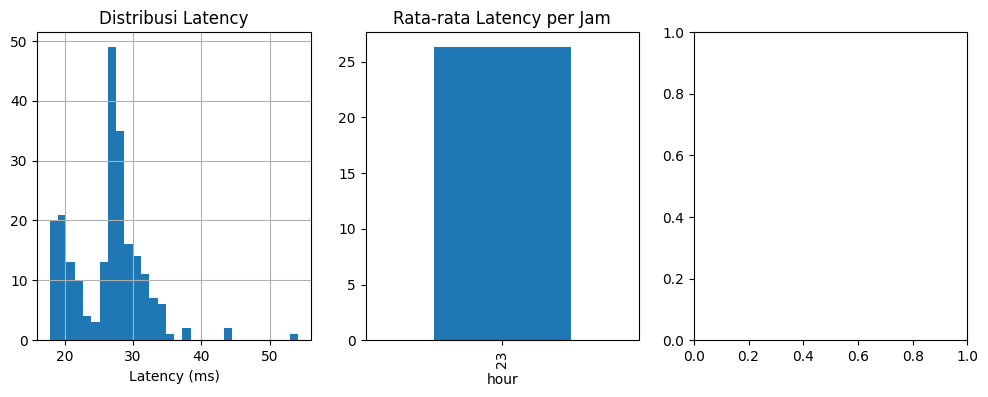

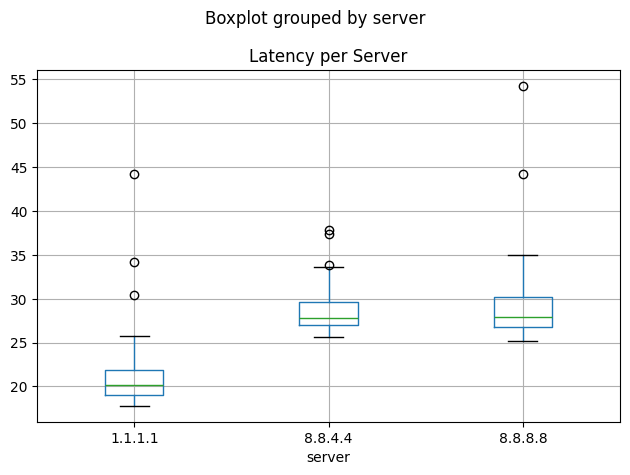

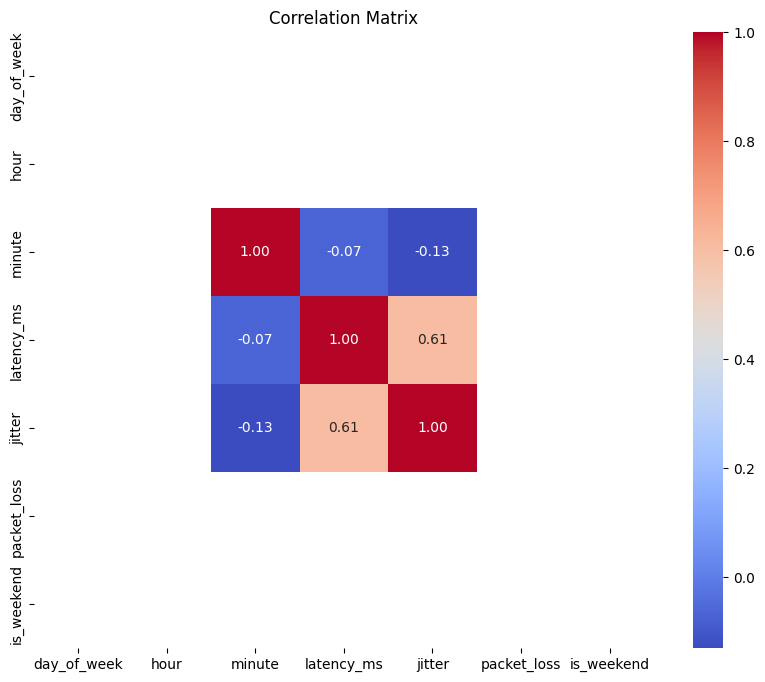

In [3]:
# Info dataset
print(df.info())
print(df.describe())

# Cek missing values
print("\nMissing values:")
print(df.isnull().sum())

# Distribusi latency
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
df['latency_ms'].hist(bins=30)
plt.title('Distribusi Latency')
plt.xlabel('Latency (ms)')

plt.subplot(1, 3, 2)
df.groupby('hour')['latency_ms'].mean().plot(kind='bar')
plt.title('Rata-rata Latency per Jam')

plt.subplot(1, 3, 3)
df.boxplot(column='latency_ms', by='server')
plt.title('Latency per Server')
plt.tight_layout()
plt.show()

# Correlation
numeric_cols = df.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# **5. Data Preprocessing**

In [5]:
# 1. Handle missing values
df = df.dropna()

# 2. Remove duplicates
df = df.drop_duplicates()

# 3. Filter invalid
df = df[df['latency_ms'] > 0]

# 4. Outlier handling (IQR)
Q1 = df['latency_ms'].quantile(0.25)
Q3 = df['latency_ms'].quantile(0.75)
IQR = Q3 - Q1
df['latency_ms'] = df['latency_ms'].clip(lower=Q1-1.5*IQR, upper=Q3+1.5*IQR)

# 5. Feature engineering
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

le = LabelEncoder()
df['server_encoded'] = le.fit_transform(df['server'])

for lag in [1, 2, 3]:
    df[f'latency_lag_{lag}'] = df['latency_ms'].shift(lag)

df['latency_rolling_mean_5'] = df['latency_ms'].rolling(5).mean()
df['latency_rolling_std_5'] = df['latency_ms'].rolling(5).std()
df['jitter_rolling_mean_5'] = df['jitter'].rolling(5).mean()
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['latency_jitter_ratio'] = df['latency_ms'] / (df['jitter'] + 1e-6)

df = df.dropna().reset_index(drop=True)

# 6. Save
df.to_csv('latency_preprocessing.csv', index=False)
print(f"Preprocessed shape: {df.shape}")
df.head()

Preprocessed shape: (220, 21)


,timestamp,server,day_of_week,hour,minute,latency_ms,jitter,packet_loss,is_weekend,server_encoded,...,latency_lag_2,latency_lag_3,latency_rolling_mean_5,latency_rolling_std_5,jitter_rolling_mean_5,hour_sin,hour_cos,dow_sin,dow_cos,latency_jitter_ratio
0,2026-05-08 23:12:06.070795,8.8.4.4,4,23,12,31.8,6.50,0.0,0,1,...,27.8,33.4,26.28,6.783215,4.50,-0.258819,0.965926,-0.433884,-0.900969,4.892307
1,2026-05-08 23:12:20.171745,8.8.8.8,4,23,12,32.6,8.25,0.0,0,2,...,19.6,27.8,29.04,5.699825,5.90,-0.258819,0.965926,-0.433884,-0.900969,3.951515
2,2026-05-08 23:12:24.265803,1.1.1.1,4,23,12,18.8,1.75,0.0,0,0,...,31.8,19.6,26.12,6.579666,4.10,-0.258819,0.965926,-0.433884,-0.900969,10.742851
3,2026-05-08 23:12:28.330617,8.8.4.4,4,23,12,31.6,7.75,0.0,0,1,...,32.6,31.8,26.88,7.026521,5.35,-0.258819,0.965926,-0.433884,-0.900969,4.077419
4,2026-05-08 23:12:42.442480,8.8.8.8,4,23,12,34.0,14.75,0.0,0,2,...,18.8,32.6,29.76,6.199032,7.80,-0.258819,0.965926,-0.433884,-0.900969,2.305085
